# Fashion-MNIST Generation Benchmark: CVAE vs DDPM

Compares the conditional VAE (`cvae_fashion_mnist.ipynb`) and class-conditioned DDPM (`stable_diffusion_fashion_mnist.ipynb`) using the same evaluation protocol. This notebook only loads checkpoints — it does not train any models.

Required checkpoints:
- `./checkpoints/cvae_fashion_mnist.pt`
- `./checkpoints/ddpm_fashion_mnist/`
- `./checkpoints/fashion_mnist_classifier.pt`

- **Conditional accuracy** — does a pretrained classifier recognize generated samples as the intended class?
- **Feature FID** — Fréchet distance between real and generated feature distributions from that same classifier
- **Generation time** — wall-clock seconds per image

Both models are evaluated with identical sample counts, seeds, and preprocessing.

## Setup

In [9]:
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

CVAE_CHECKPOINT = "./checkpoints/cvae_fashion_mnist.pt"
DDPM_CHECKPOINT_DIR = "./checkpoints/ddpm_fashion_mnist"
CLASSIFIER_CHECKPOINT = "./checkpoints/fashion_mnist_classifier.pt"

NUM_CLASSES = 10
IMAGE_SIZE = 28
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE
LATENT_DIM = 20
HIDDEN_DIM = 400
NUM_TRAIN_TIMESTEPS = 1000
DDPM_INFERENCE_STEPS = 200

BENCHMARK_BATCH_SIZE = 128
NUM_SAMPLES_PER_CLASS = 200
BASE_SEED = 0

CLASS_NAMES = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

mps


## Data

In [10]:
transform = transforms.ToTensor()

test_data = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=BENCHMARK_BATCH_SIZE)

print(len(test_data))

10000


## Load checkpoints

Loads the benchmark classifier, CVAE, and DDPM from disk. The classifier provides the shared feature space for conditional accuracy and FID.

In [11]:
class FashionClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.head = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x):
        return self.head(self.features(x))

    def encode(self, x):
        return self.features(x)


def load_classifier(path):
    model = FashionClassifier().to(device)
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"loaded classifier from {path}")
    if "test_accuracy" in checkpoint:
        print(f"checkpoint test acc: {checkpoint['test_accuracy']:.4f}")
    return model


def classifier_accuracy(model, images, target_labels):
    model.eval()
    with torch.no_grad():
        preds = model(images.to(device)).argmax(1).cpu()
    return (preds == target_labels).float().mean().item()


class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(IMAGE_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, IMAGE_DIM),
            nn.Sigmoid(),
        )

    def decode(self, z, y):
        return self.decoder(torch.cat([z, y], dim=1))


def load_cvae(path):
    model = CVAE().to(device)
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"loaded CVAE from {path}")
    return model


def load_ddpm(checkpoint_dir):
    unet = UNet2DModel.from_pretrained(os.path.join(checkpoint_dir, "unet")).to(device)
    scheduler = DDPMScheduler.from_pretrained(os.path.join(checkpoint_dir, "scheduler"))
    unet.eval()
    print(f"loaded DDPM from {checkpoint_dir}")
    return unet, scheduler


classifier = load_classifier(CLASSIFIER_CHECKPOINT)
cvae = load_cvae(CVAE_CHECKPOINT)
ddpm_unet, ddpm_scheduler = load_ddpm(DDPM_CHECKPOINT_DIR)

loaded classifier from ./checkpoints/fashion_mnist_classifier.pt
checkpoint test acc: 0.9004
loaded CVAE from ./checkpoints/cvae_fashion_mnist.pt
loaded DDPM from ./checkpoints/ddpm_fashion_mnist


## Shared generation helpers

All generated images are returned as `(N, 1, 28, 28)` tensors in `[0, 1]` for fair comparison.

In [12]:
def labels_to_onehot(labels):
    return F.one_hot(labels, NUM_CLASSES).float()


def to_unit_range(images):
    if images.ndim == 4:
        return images.clamp(0, 1)
    return images.clamp(0, 1).unsqueeze(1)


@torch.no_grad()
def generate_cvae_batch(model, class_idx, n, seed):
    generator = torch.Generator(device=device).manual_seed(seed)
    z = torch.randn(n, LATENT_DIM, generator=generator, device=device)
    labels = torch.full((n,), class_idx, dtype=torch.long, device=device)
    y = labels_to_onehot(labels)
    flat = model.decode(z, y)
    return flat.view(n, 1, IMAGE_SIZE, IMAGE_SIZE)


@torch.no_grad()
def generate_ddpm_batch(unet, scheduler, class_idx, n, seed, steps=DDPM_INFERENCE_STEPS):
    unet.eval()
    scheduler.set_timesteps(steps)
    generator = torch.Generator(device=device).manual_seed(seed)
    samples = torch.randn(
        n, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    labels = torch.full((n,), class_idx, dtype=torch.long, device=device)
    for t in scheduler.timesteps:
        noise_pred = unet(samples, t, class_labels=labels).sample
        samples = scheduler.step(noise_pred, t, samples).prev_sample
    return samples.clamp(-1, 1).add(1).div(2)


def generate_all_classes(generator_fn, samples_per_class=NUM_SAMPLES_PER_CLASS, base_seed=BASE_SEED):
    images = []
    labels = []
    timings = []
    for class_idx in range(NUM_CLASSES):
        remaining = samples_per_class
        class_images = []
        class_time = 0.0
        batch_idx = 0
        while remaining > 0:
            batch_size = min(BENCHMARK_BATCH_SIZE, remaining)
            seed = base_seed + class_idx * 10_000 + batch_idx
            start = time.perf_counter()
            batch = generator_fn(class_idx, batch_size, seed)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elif device.type == "mps":
                torch.mps.synchronize()
            class_time += time.perf_counter() - start
            class_images.append(to_unit_range(batch).cpu())
            remaining -= batch_size
            batch_idx += 1
        class_images = torch.cat(class_images)
        images.append(class_images)
        labels.append(torch.full((samples_per_class,), class_idx, dtype=torch.long))
        timings.append(class_time / samples_per_class)
    return torch.cat(images), torch.cat(labels), timings

## Benchmark metrics

In [13]:
@torch.no_grad()
def extract_features(model, images, batch_size=BENCHMARK_BATCH_SIZE):
    model.eval()
    feats = []
    for start in range(0, len(images), batch_size):
        batch = images[start : start + batch_size].to(device)
        feats.append(model.encode(batch).cpu())
    return torch.cat(feats).numpy()


def frechet_distance(mu1, sigma1, mu2, sigma2):
    from scipy.linalg import sqrtm

    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))


def compute_feature_fid(real_features, fake_features):
    mu_real = real_features.mean(axis=0)
    mu_fake = fake_features.mean(axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    return frechet_distance(mu_real, sigma_real, mu_fake, sigma_fake)


def per_class_accuracy(images, labels):
    accs = []
    for class_idx in range(NUM_CLASSES):
        mask = labels == class_idx
        class_images = images[mask]
        target = torch.full((len(class_images),), class_idx, dtype=torch.long)
        accs.append(classifier_accuracy(classifier, class_images, target))
    return accs


def evaluate_model(name, images, labels, per_class_times, real_features):
    fake_features = extract_features(classifier, images)
    class_accs = per_class_accuracy(images, labels)
    return {
        "model": name,
        "conditional_accuracy": float(np.mean(class_accs)),
        "per_class_accuracy": class_accs,
        "feature_fid": compute_feature_fid(real_features, fake_features),
        "seconds_per_image": float(np.mean(per_class_times)),
        "per_class_seconds": per_class_times,
    }

## Run benchmark

In [14]:
real_images = []
real_labels = []
for images, labels in test_loader:
    real_images.append(images)
    real_labels.append(labels)
    if sum(len(x) for x in real_images) >= NUM_SAMPLES_PER_CLASS * NUM_CLASSES:
        break

real_images = torch.cat(real_images)[: NUM_SAMPLES_PER_CLASS * NUM_CLASSES]
real_labels = torch.cat(real_labels)[: NUM_SAMPLES_PER_CLASS * NUM_CLASSES]
real_features = extract_features(classifier, real_images)

print("generating CVAE samples...")
cvae_images, cvae_labels, cvae_times = generate_all_classes(
    lambda class_idx, n, seed: generate_cvae_batch(cvae, class_idx, n, seed)
)

print("generating DDPM samples...")
ddpm_images, ddpm_labels, ddpm_times = generate_all_classes(
    lambda class_idx, n, seed: generate_ddpm_batch(
        ddpm_unet, ddpm_scheduler, class_idx, n, seed
    )
)

results = [
    evaluate_model("CVAE", cvae_images, cvae_labels, cvae_times, real_features),
    evaluate_model("DDPM", ddpm_images, ddpm_labels, ddpm_times, real_features),
]

print("\n=== Benchmark summary ===")
for row in results:
    print(
        f"{row['model']:>4} | "
        f"acc={row['conditional_accuracy']:.3f} | "
        f"fid={row['feature_fid']:.2f} | "
        f"sec/img={row['seconds_per_image']:.4f}"
    )

generating CVAE samples...
generating DDPM samples...


/var/folders/w3/5cjnw3xn1jg8w2z_kphmf1840000gn/T/ipykernel_58394/1633576648.py:15: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)



=== Benchmark summary ===
CVAE | acc=0.632 | fid=124.41 | sec/img=0.0000
DDPM | acc=0.831 | fid=40.78 | sec/img=0.3676


## Per-class breakdown

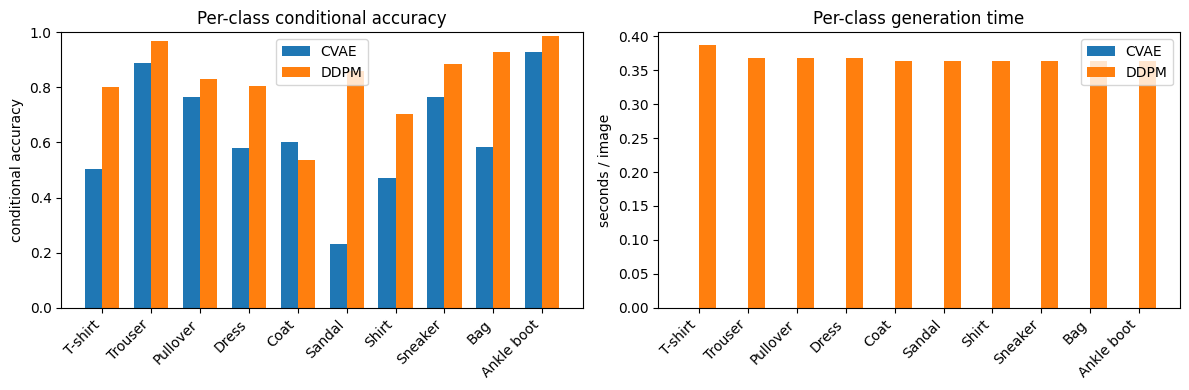

In [17]:
x = np.arange(NUM_CLASSES)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x - width / 2, results[0]["per_class_accuracy"], width, label="CVAE")
axes[0].bar(x + width / 2, results[1]["per_class_accuracy"], width, label="DDPM")
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
axes[0].set_ylabel("conditional accuracy")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_title("Per-class conditional accuracy")

axes[1].bar(x - width / 2, results[0]["per_class_seconds"], width, label="CVAE")
axes[1].bar(x + width / 2, results[1]["per_class_seconds"], width, label="DDPM")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("seconds / image")
axes[1].legend()
axes[1].set_title("Per-class generation time")

plt.tight_layout()
plt.show()

## Visual comparison

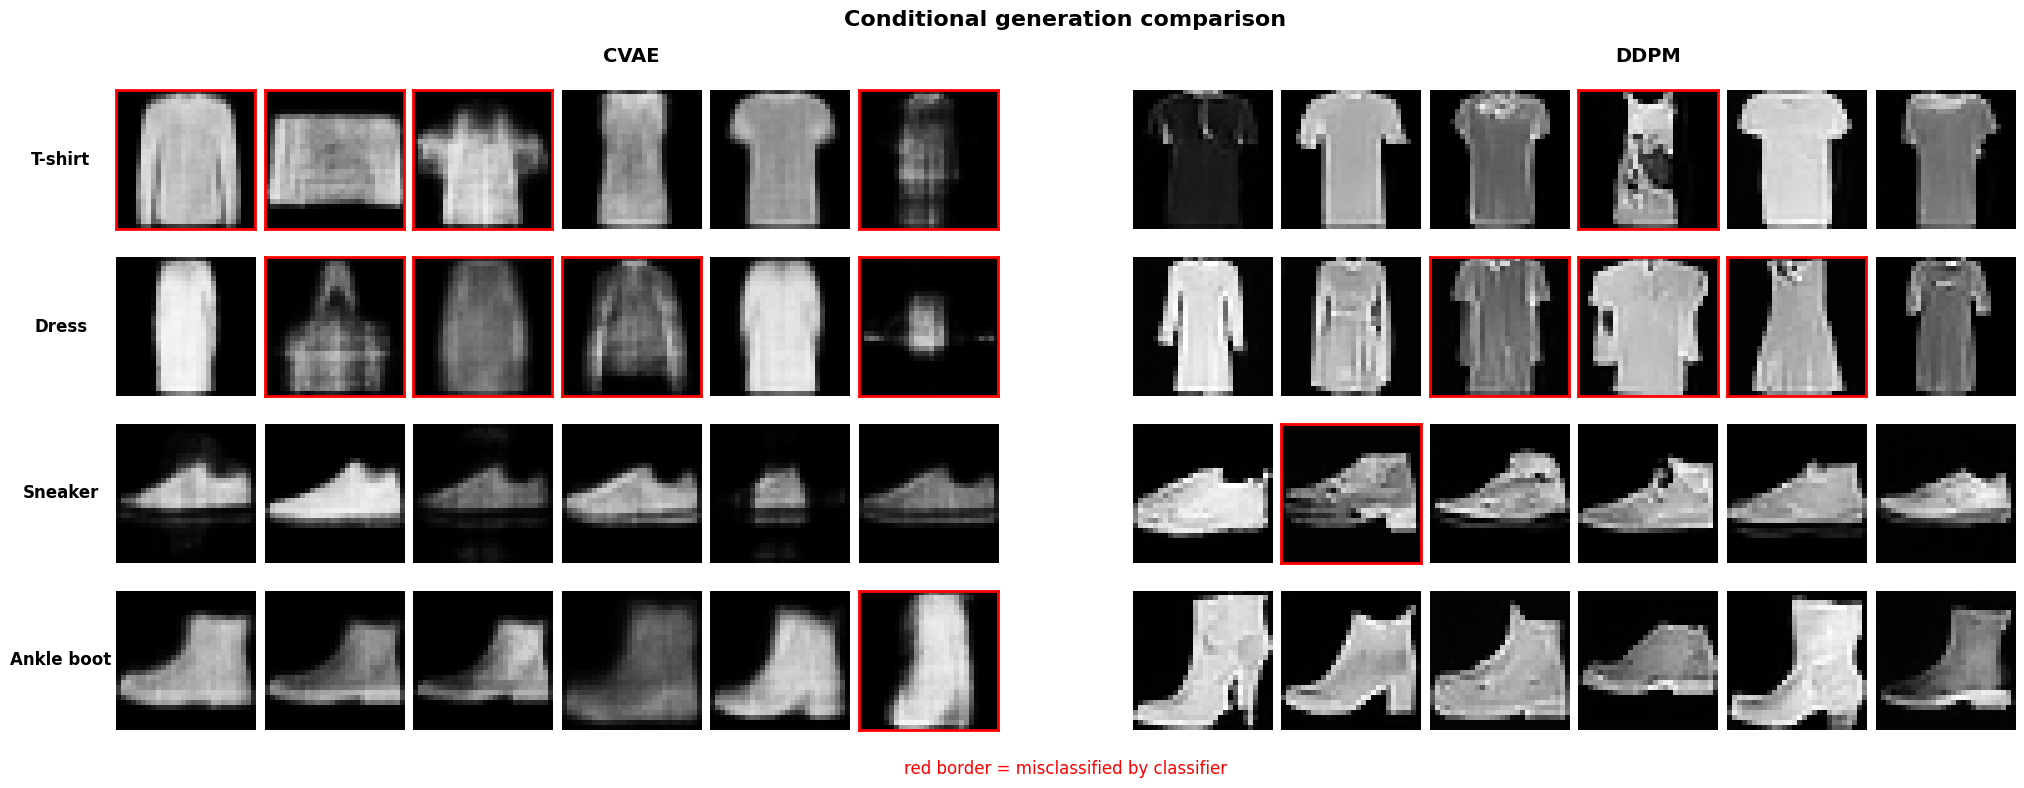

In [27]:
from matplotlib.gridspec import GridSpec

def sample_class_images(images, labels, class_idx, n, seed):
    rng = np.random.default_rng(seed)
    pool = images[labels == class_idx]
    pick = rng.choice(len(pool), size=min(n, len(pool)), replace=False)
    return pool[pick]

def get_misclassified_mask(model, images, target_class_idx):
    model.eval()
    with torch.no_grad():
        preds = model(images.to(device)).argmax(1).cpu()
    return preds != target_class_idx

COMPARE_CLASSES = [0, 3, 7, 9]
SAMPLES_PER_MODEL = 6

fig = plt.figure(figsize=(1.8 * SAMPLES_PER_MODEL * 2, 2.0 * len(COMPARE_CLASSES)))
gs = GridSpec(
    len(COMPARE_CLASSES),
    2,
    figure=fig,
    wspace=0.15,
    hspace=0.2,
    left=0.1,
    right=0.98,
    top=0.88,
    bottom=0.08,
)

for row, class_idx in enumerate(COMPARE_CLASSES):
    cvae_samples = sample_class_images(cvae_images, cvae_labels, class_idx, SAMPLES_PER_MODEL, seed=class_idx)
    ddpm_samples = sample_class_images(ddpm_images, ddpm_labels, class_idx, SAMPLES_PER_MODEL, seed=class_idx)

    cvae_misclassified = get_misclassified_mask(classifier, cvae_samples, class_idx)
    ddpm_misclassified = get_misclassified_mask(classifier, ddpm_samples, class_idx)

    cvae_gs = gs[row, 0].subgridspec(1, SAMPLES_PER_MODEL, wspace=0.05)
    ddpm_gs = gs[row, 1].subgridspec(1, SAMPLES_PER_MODEL, wspace=0.05)

    for col in range(SAMPLES_PER_MODEL):
        ax_cvae = fig.add_subplot(cvae_gs[0, col])
        ax_cvae.imshow(cvae_samples[col, 0], cmap="gray", vmin=0, vmax=1)
        ax_cvae.set_xticks([])
        ax_cvae.set_yticks([])
        for spine in ax_cvae.spines.values():
            spine.set_visible(cvae_misclassified[col])
            if cvae_misclassified[col]:
                spine.set_color("red")
                spine.set_linewidth(2)

        ax_ddpm = fig.add_subplot(ddpm_gs[0, col])
        ax_ddpm.imshow(ddpm_samples[col, 0], cmap="gray", vmin=0, vmax=1)
        ax_ddpm.set_xticks([])
        ax_ddpm.set_yticks([])
        for spine in ax_ddpm.spines.values():
            spine.set_visible(ddpm_misclassified[col])
            if ddpm_misclassified[col]:
                spine.set_color("red")
                spine.set_linewidth(2)

        if row == 0 and col == SAMPLES_PER_MODEL // 2:
            ax_cvae.set_title("CVAE", fontsize=14, fontweight="bold", pad=20)
            ax_ddpm.set_title("DDPM", fontsize=14, fontweight="bold", pad=20)
            
        if col == 0:
            ax_cvae.set_ylabel(CLASS_NAMES[class_idx], fontsize=12, fontweight="bold", rotation=0, labelpad=40, va="center")

fig.suptitle("Conditional generation comparison", fontsize=16, x=0.54, y=0.98, fontweight="bold")
fig.text(0.54, 0.02, "red border = misclassified by classifier", ha="center", va="bottom", fontsize=12, color="red")
plt.show()